In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
import matplotlib.pyplot as plt
import pandas as pd

In [168]:
data=pd.read_csv('Shoppers_Behaviour_and_Revenue.csv')
data.shape

(12330, 18)

In [169]:
print("First 5 Rows...",data.head())

First 5 Rows...    Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0     

In [170]:
data.columns = data.columns.str.strip()
print(data.columns)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='str')


In [171]:
print(data.isnull().sum().sum())

0


In [172]:
print(data.dtypes)

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object


In [173]:
print(data.duplicated().sum())

125


In [174]:
data = data.drop_duplicates()
data.shape

(12205, 18)

In [175]:
print(data["Month"].value_counts())
print(data["VisitorType"].value_counts())
print(data["Weekend"].value_counts())
print(data["Revenue"].value_counts())

Month
May     3329
Nov     2982
Mar     1860
Dec     1706
Oct      549
Sep      448
Aug      433
Jul      432
June     285
Feb      181
Name: count, dtype: int64
VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64
Weekend
False    9346
True     2859
Name: count, dtype: int64
Revenue
False    10297
True      1908
Name: count, dtype: int64


In [176]:
numeric_df = data.select_dtypes(
    include=["int64", "float64"]
)

correlation = numeric_df.corr()
print(correlation)

                         Administrative  Administrative_Duration  \
Administrative                 1.000000                 0.600457   
Administrative_Duration        0.600457                 1.000000   
Informational                  0.375256                 0.301419   
Informational_Duration         0.254813                 0.237211   
ProductRelated                 0.428305                 0.286863   
ProductRelated_Duration        0.371146                 0.353583   
BounceRates                   -0.213096                -0.136913   
ExitRates                     -0.311255                -0.201971   
PageValues                     0.097017                 0.066228   
SpecialDay                    -0.096951                -0.074666   
OperatingSystems              -0.006586                -0.007529   
Browser                       -0.025622                -0.015742   
Region                        -0.007262                -0.006729   
TrafficType                   -0.034643         

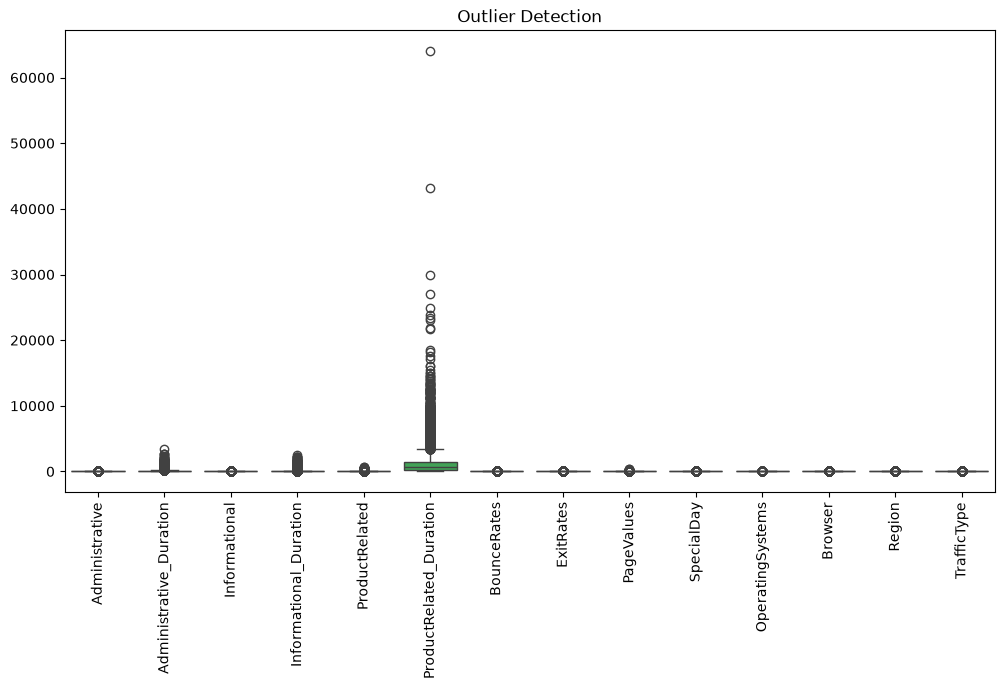

In [184]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=numeric_df)
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

In [178]:
data["Month"] = data["Month"].map({
    "Jan": 1,
    "Feb": 2,
    "Mar": 3,
    "Apr": 4,
    "May": 5,
    "June": 6,
    "Jul": 7,
    "Aug": 8,
    "Sep": 9,
    "Oct": 10,
    "Nov": 11,
    "Dec": 12
})

In [179]:
data["VisitorType"] = data["VisitorType"].map({
    "Returning_Visitor": 0,
    "New_Visitor": 1,
    "Other": 2
})

In [180]:
X = data.drop("Revenue", axis=1)
y = data["Revenue"]

In [181]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [182]:
print(X_train.shape)
print(y_train.shape)

(9764, 17)
(9764,)


In [199]:
for depth in [1, 2, 3, 4, 5]:
    weak_tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    model = AdaBoostClassifier(
        estimator=weak_tree,
        n_estimators=200,
        learning_rate=0.3,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("Max Depth:", depth,"| Accuracy:", round(accuracy * 100, 2), "%")

Max Depth: 1 | Accuracy: 88.69 %
Max Depth: 2 | Accuracy: 89.92 %
Max Depth: 3 | Accuracy: 90.13 %
Max Depth: 4 | Accuracy: 90.45 %
Max Depth: 5 | Accuracy: 90.17 %
